In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# load dataset
df = pd.read_csv("churn_dataset_600_rows.csv")

print("shape:", df.shape)
print("\nfirst 5 rows:")
print(df.head())

shape: (600, 11)

first 5 rows:
  customer_id  gender  age  tenure  monthly_charges  total_charges  \
0       C0001    Male   19      48               57           2736   
1       C0002    Male   55      28               42           1176   
2       C0003    Male   63      42               84           3528   
3       C0004    Male   28      45               67           3015   
4       C0005  Female   24      23               94           2162   

  contract_type internet_service  support_calls payment_method churn  
0       Monthly              DSL              5           Card    No  
1       Monthly              DSL              1           Cash    No  
2       Monthly              DSL              3           Cash   Yes  
3       Monthly              DSL              1            UPI   Yes  
4       Monthly            Fiber              0           Cash    No  


In [17]:
print("Missing values by column:")
print(df.isna().sum())

print("\nChurn distribution:")
churn_counts = df["churn"].value_counts()
print(churn_counts)

print("\nChurn percentage:")
print((df["churn"].value_counts(normalize=True) * 100).round(2))

print("\nNumeric summary:")
print(df.describe())

Missing values by column:
customer_id           0
gender                0
age                   0
tenure                0
monthly_charges       0
total_charges         0
contract_type         0
internet_service    195
support_calls         0
payment_method        0
churn                 0
dtype: int64

Churn distribution:
churn
No     307
Yes    293
Name: count, dtype: int64

Churn percentage:
churn
No     51.17
Yes    48.83
Name: proportion, dtype: float64

Numeric summary:
              age      tenure  monthly_charges  total_charges  support_calls
count  600.000000  600.000000        600.00000     600.000000     600.000000
mean    42.353333   30.250000         69.85000    2091.220000       2.478333
std     13.676753   17.028921         17.58967    1304.667114       1.648452
min     18.000000    1.000000         40.00000      43.000000       0.000000
25%     31.000000   15.000000         54.75000    1048.500000       1.000000
50%     42.000000   31.000000         70.00000    2015.000

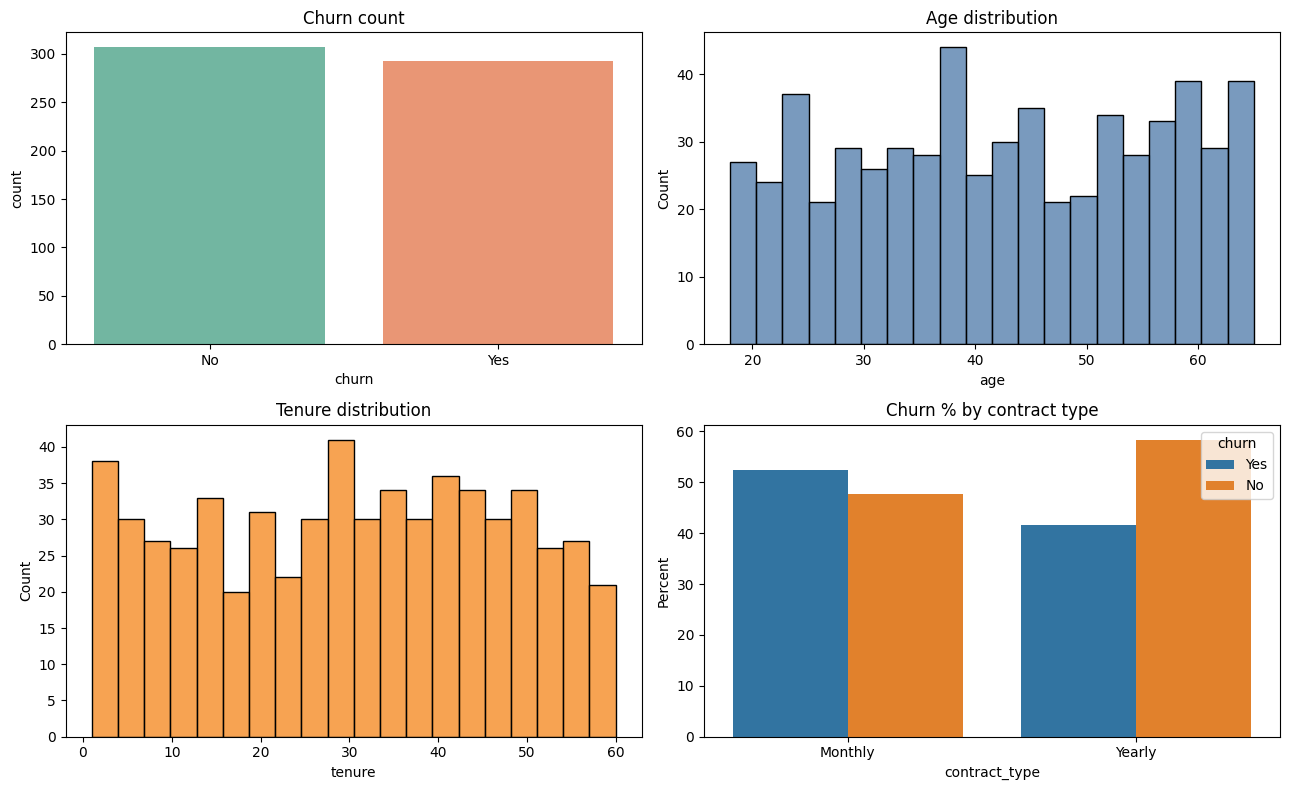

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.countplot(data=df, x="churn", hue="churn", palette="Set2", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Churn count")

sns.histplot(data=df, x="age", bins=20, kde=False, color="#4C78A8", ax=axes[0, 1])
axes[0, 1].set_title("Age distribution")

sns.histplot(data=df, x="tenure", bins=20, kde=False, color="#F58518", ax=axes[1, 0])
axes[1, 0].set_title("Tenure distribution")

contract_churn = (
    df.groupby("contract_type")["churn"]
    .value_counts(normalize=True)
    .rename("ratio")
    .mul(100)
    .reset_index()
)
sns.barplot(data=contract_churn, x="contract_type", y="ratio", hue="churn", ax=axes[1, 1])
axes[1, 1].set_title("Churn % by contract type")
axes[1, 1].set_ylabel("Percent")

plt.tight_layout()
plt.show()

In [19]:
# quick cleanup before modeling
data = df.copy()
data["internet_service"] = data["internet_service"].fillna("Unknown")

X = data.drop(columns=["customer_id", "churn"])
y = data["churn"].map({"No": 0, "Yes": 1})

categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("categorical columns:", categorical_cols)
print("numeric columns:", numeric_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\ntrain rows: {X_train.shape[0]}")
print(f"test rows:  {X_test.shape[0]}")

categorical columns: ['gender', 'contract_type', 'internet_service', 'payment_method']
numeric columns: ['age', 'tenure', 'monthly_charges', 'total_charges', 'support_calls']

train rows: 480
test rows:  120


In [20]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }

    print(f"\n{name}")
    print("-" * len(name))
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

    return metrics, y_pred

log_reg = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=42)),
    ]
)
log_reg.fit(X_train, y_train)

lr_metrics, y_pred_lr = evaluate_model("Logistic Regression", log_reg, X_test, y_test)


Logistic Regression
-------------------
Accuracy: 0.5583
Precision: 0.5652
Recall: 0.4407
ROC-AUC: 0.6552

Confusion matrix:
[[41 20]
 [33 26]]

Classification report:
              precision    recall  f1-score   support

    No churn       0.55      0.67      0.61        61
       Churn       0.57      0.44      0.50        59

    accuracy                           0.56       120
   macro avg       0.56      0.56      0.55       120
weighted avg       0.56      0.56      0.55       120



In [21]:
random_forest = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=None,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
random_forest.fit(X_train, y_train)

rf_metrics, y_pred_rf = evaluate_model("Random Forest", random_forest, X_test, y_test)


Random Forest
-------------
Accuracy: 0.6000
Precision: 0.6122
Recall: 0.5085
ROC-AUC: 0.6173

Confusion matrix:
[[42 19]
 [29 30]]

Classification report:
              precision    recall  f1-score   support

    No churn       0.59      0.69      0.64        61
       Churn       0.61      0.51      0.56        59

    accuracy                           0.60       120
   macro avg       0.60      0.60      0.60       120
weighted avg       0.60      0.60      0.60       120



Model comparison:
                     Accuracy  Precision  Recall  ROC-AUC
Model                                                    
Logistic Regression    0.5583     0.5652  0.4407   0.6552
Random Forest          0.6000     0.6122  0.5085   0.6173

Auto metric: ROC-AUC
Final model selected: Logistic Regression


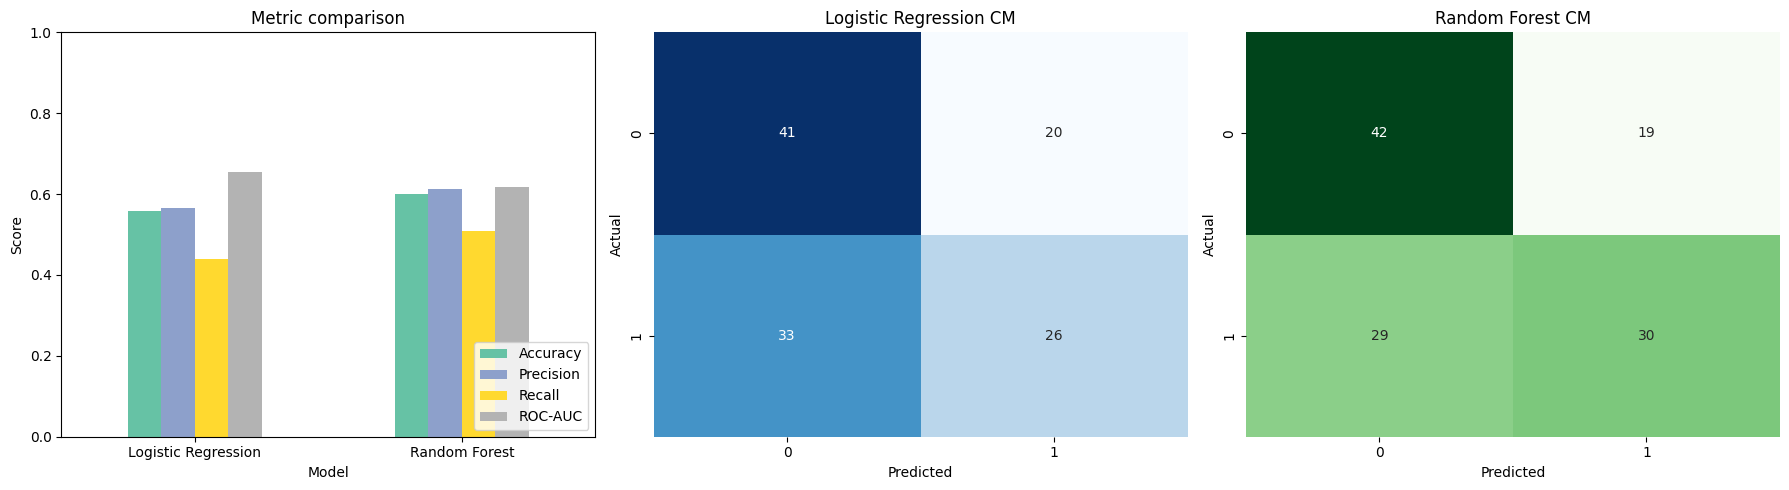


Conclusion:
Using Logistic Regression for final predictions.


In [25]:
results = pd.DataFrame([lr_metrics, rf_metrics]).set_index("Model")
print("Model comparison:")
print(results.round(4))

# How to choose final model:
# 1) Set MANUAL_FINAL_MODEL to "Random Forest" or "Logistic Regression" to force it.
# 2) Keep it None to auto-select by AUTO_SELECT_METRIC.
MANUAL_FINAL_MODEL = None
AUTO_SELECT_METRIC = "ROC-AUC"  # try "Accuracy" if you want to prioritize accuracy

if MANUAL_FINAL_MODEL in results.index:
    final_model_name = MANUAL_FINAL_MODEL
else:
    final_model_name = results[AUTO_SELECT_METRIC].idxmax()

final_model = random_forest if final_model_name == "Random Forest" else log_reg

print(f"\nAuto metric: {AUTO_SELECT_METRIC}")
print(f"Final model selected: {final_model_name}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results.plot(kind="bar", ax=axes[0], ylim=(0, 1), rot=0, colormap="Set2")
axes[0].set_title("Metric comparison")
axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Logistic Regression CM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[2])
axes[2].set_title("Random Forest CM")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("\nConclusion:")
print(f"Using {final_model_name} for final predictions.")

## 6) Test with New Customer Data
Create one new customer record and check predicted churn.

In [26]:
new_customer = pd.DataFrame([
    {
        "gender": "Female",
        "age": 46,
        "tenure": 8,
        "monthly_charges": 95,
        "total_charges": 760,
        "contract_type": "Monthly",
        "internet_service": "Fiber",
        "support_calls": 4,
        "payment_method": "Cash",
    }
])

print("New customer input:")
print(new_customer)

lr_prob = log_reg.predict_proba(new_customer)[0, 1]
rf_prob = random_forest.predict_proba(new_customer)[0, 1]

lr_label = "Yes" if lr_prob >= 0.5 else "No"
rf_label = "Yes" if rf_prob >= 0.5 else "No"

print("\nPrediction output:")
print(f"Logistic Regression -> Churn: {lr_label}, Probability: {lr_prob:.2%}")
print(f"Random Forest       -> Churn: {rf_label}, Probability: {rf_prob:.2%}")

final_prob = final_model.predict_proba(new_customer)[0, 1]
final_label = "Yes" if final_prob >= 0.5 else "No"
print(f"\nFinal ({final_model_name}) -> Churn: {final_label}, Probability: {final_prob:.2%}")

New customer input:
   gender  age  tenure  monthly_charges  total_charges contract_type  \
0  Female   46       8               95            760       Monthly   

  internet_service  support_calls payment_method  
0            Fiber              4           Cash  

Prediction output:
Logistic Regression -> Churn: Yes, Probability: 71.42%
Random Forest       -> Churn: Yes, Probability: 51.20%

Final (Logistic Regression) -> Churn: Yes, Probability: 71.42%


In [27]:
# another sample input (expected: No churn)
new_customer_no = pd.DataFrame([
    {
        "gender": "Male",
        "age": 52,
        "tenure": 56,
        "monthly_charges": 49,
        "total_charges": 2744,
        "contract_type": "Yearly",
        "internet_service": "DSL",
        "support_calls": 0,
        "payment_method": "Card",
    }
])

print("New customer input (No churn test):")
print(new_customer_no)

lr_prob_no = log_reg.predict_proba(new_customer_no)[0, 1]
rf_prob_no = random_forest.predict_proba(new_customer_no)[0, 1]

lr_label_no = "Yes" if lr_prob_no >= 0.5 else "No"
rf_label_no = "Yes" if rf_prob_no >= 0.5 else "No"

print("\nPrediction output:")
print(f"Logistic Regression -> Churn: {lr_label_no}, Probability: {lr_prob_no:.2%}")
print(f"Random Forest       -> Churn: {rf_label_no}, Probability: {rf_prob_no:.2%}")

final_prob_no = final_model.predict_proba(new_customer_no)[0, 1]
final_label_no = "Yes" if final_prob_no >= 0.5 else "No"
print(f"\nFinal ({final_model_name}) -> Churn: {final_label_no}, Probability: {final_prob_no:.2%}")

New customer input (No churn test):
  gender  age  tenure  monthly_charges  total_charges contract_type  \
0   Male   52      56               49           2744        Yearly   

  internet_service  support_calls payment_method  
0              DSL              0           Card  

Prediction output:
Logistic Regression -> Churn: No, Probability: 24.65%
Random Forest       -> Churn: No, Probability: 34.40%

Final (Logistic Regression) -> Churn: No, Probability: 24.65%


In [28]:
# sample input where final decision is explicitly based on Random Forest
rf_final_customer = pd.DataFrame([
    {
        "gender": "Female",
        "age": 39,
        "tenure": 14,
        "monthly_charges": 88,
        "total_charges": 1232,
        "contract_type": "Monthly",
        "internet_service": "Fiber",
        "support_calls": 3,
        "payment_method": "UPI",
    }
])

print("Random Forest final input:")
print(rf_final_customer)

lr_prob_rf_case = log_reg.predict_proba(rf_final_customer)[0, 1]
rf_prob_rf_case = random_forest.predict_proba(rf_final_customer)[0, 1]

lr_label_rf_case = "Yes" if lr_prob_rf_case >= 0.5 else "No"
rf_label_rf_case = "Yes" if rf_prob_rf_case >= 0.5 else "No"

print("\nBoth model outputs:")
print(f"Logistic Regression -> Churn: {lr_label_rf_case}, Probability: {lr_prob_rf_case:.2%}")
print(f"Random Forest       -> Churn: {rf_label_rf_case}, Probability: {rf_prob_rf_case:.2%}")

# force final output to Random Forest for this example
final_model_name_rf_case = "Random Forest"
final_prob_rf_case = rf_prob_rf_case
final_label_rf_case = rf_label_rf_case

print(f"\nFinal ({final_model_name_rf_case}) -> Churn: {final_label_rf_case}, Probability: {final_prob_rf_case:.2%}")

Random Forest final input:
   gender  age  tenure  monthly_charges  total_charges contract_type  \
0  Female   39      14               88           1232       Monthly   

  internet_service  support_calls payment_method  
0            Fiber              3            UPI  

Both model outputs:
Logistic Regression -> Churn: Yes, Probability: 53.76%
Random Forest       -> Churn: No, Probability: 49.20%

Final (Random Forest) -> Churn: No, Probability: 49.20%
